### Trabalho 1: Replicação de "A Bibliometric Analysis of Edge Computing for Internet of Things"

***

#### 0: Setup inicial do dataframe

In [ ]:

import pandas as pd
import numpy as np


df = pd.read_csv('Base Consolidada 2025.csv')


ParserError: Error tokenizing data. C error: Expected 7 fields in line 3, saw 8


***

#### 1: Analysis of Core Literature Studies

> *3.1. Analysis of Core Literature Studies.* The main literature studies on EC-IoT were highlighted. The top 10 most cited literatures in the world are listed in Table 1. These literature studies have had the widest influence in EC-IoT.

- Nesta seção, eles mostram quais papers são os mais citados e influentes
- Aqui, esperamos ter resultados bem similares (senão iguais) aos deles, dado que os papers seminais do campo não vão ter mudado de 2020 pra hoje
- Acredito que esse resultado é apenas uma lista de 10 artigos ordenadas pelo maior **número total** de citações, com o número médio de citações calculado a partir do ano de publicação do paper.
	- por ex.: eles usam o número de citações feitas apenas por outros artigos na base, ou buscam esse # total em outras fontes também?

Formato do resultado final: (10 linhas no total, 3 mostradas aqui por brevidade)

| Number | Literature title                                                 | Total citation | Average citation per year |
| ------ | ---------------------------------------------------------------- | -------------- | ------------------------- |
| 1      | Edge Computing: Vision and Challenges                            | 1342           | 268.4                     |
| 2      | A Survey on Mobile Edge Computing: The Communication Perspective | 836            | 209                       |
| 3      | Fog and IoT: An Overview of Research Opportunities               | 801            | 160.2                     |

**Não esquecer de somar 1 à quantidade de anos para o denominador do número médio de citações. Os autores fazem isso porque a pesquisa foi feita no final do ano de 2020.**

In [7]:
df = df.sort_values(by="Times Cited, All Databases", ascending=False)

CURRENT_YEAR = 2025

mostCited10 = df.loc[0:9, ["Article Title", "Times Cited, All Databases", "Publication Year"]] #Os autores originais não especificam qual coluna utilizaram, assumindo "All databases" 
mostCited10["Years since Publication"] = CURRENT_YEAR - mostCited10["Publication Year"] + 1 #Soma 1 para considerar 2025 como um ano completo para a média de citações por ano
mostCited10["Average citations per year"] = mostCited10["Times Cited, All Databases"] / mostCited10["Years since Publication"]

mostCited10[["Article Title", "Times Cited, All Databases", "Average citations per year"]].to_csv("output_analise1.csv")

***

#### 2: Analysis of Core Journals

> *3.2. Analysis of Core Journals.* In the development of EC-IoT, journals play an important role as the main disseminators of the process of studies. The top 7 leading journals with the most published literatures in the EC-IoT field are listed in Table 2.
> 
> ...
> 
> Among them, IEEE Access has published 279 literature studies in this field, ranking first. Meanwhile, the total number of literature studies published by the journals listed in Table 2 reaches 832, accounting for about 30% of all literature studies retrieved
> 
> ...
> 
>  Next, the journal citation totals [33, 34] were studied, that is, the most cited journal and the journal frequently cited by the same source. The minimum number of citations of journals was set 50 in VOSviewer. A visualization of journal cocitation network is shown in Figure 1. In Figure 1, the sizes of dots and words represent the cited times. The larger the dots and words are, the more times they are cited. It can be seen from Figure 1 that IEEE Access and IEEE Internet of Things are cited the most times
> 
>  ...

- Apresentam os top 7 *journals* em número de artigos publicados
	- Por quê 7 não é explicado no artigo, mas vamos manter o mesmo número para a replicação
- Dizem que **30%** das publicações são feitas pelos top 7. Se não houve grande mudança na estrutura destes journals ou mudança de preferências por autores, devemos encontrar aproximadamente o mesmo número, mas não é garantido
- Não explicam a metodologia exata para o "impact Factor", mas olhando online parece ser uma fórmula padrão. provavelmente conseguimos puxar o impact factor de cada um dos top 7 jpurnals que acharmos da internet mesmo, daí adicionamos nas fontes
	- Como nossa base está consolidada com todas as citações desde 2000, não temos calcular o impact factor nós mesmos, só se formos baixar novas bases do WoS.

**Tabela 1:**

<img src="Images/Pasted image 20250816182957.png">

Imagem da tabela salva como 'tabela_analise2.png'

--- Análise 2: Top 7 Periódicos (Core Journals) ---

                                 Periódico (Journal)  Número de Artigos  \
1                                         BIOSYSTEMS                  5   
2  JOURNAL OF COMPUTATIONAL AND THEORETICAL NANOS...                  4   
3            ANGEWANDTE CHEMIE-INTERNATIONAL EDITION                  3   
4                   JOURNAL OF COMPUTATIONAL BIOLOGY                  3   
5                IEEE TRANSACTIONS ON NANOBIOSCIENCE                  3   
6      IEEE TRANSACTIONS ON EVOLUTIONARY COMPUTATION                  2   
7  INTERNATIONAL JOURNAL OF INNOVATIVE COMPUTING ...                  2   

  Fator de Impacto (JCR 2023)  
1                         NaN  
2                         NaN  
3                         NaN  
4                         NaN  
5                         NaN  
6                         NaN  
7                         NaN  


Número total de artigos na base de da

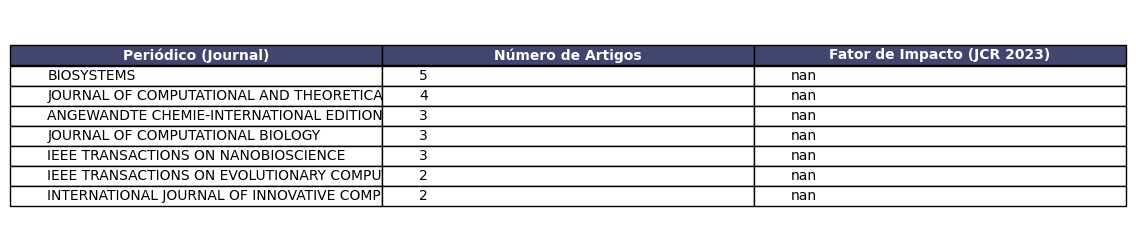

In [8]:
# Capraro: Análise 2 - Top 7 Journals
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# A linha abaixo é apenas um lembrete.
# O seu DataFrame 'df' já deve estar carregado
# após a execução da primeira célula do notebook.
# df = pd.read_csv('Base Consolidada 2025.csv')

# --- Início do Código Modificado para a Análise 2 ---

# Passo 1: Contar o número de publicações por periódico.
journal_counts = df['Source Title'].value_counts()

# Passo 2: Selecionar os 7 periódicos com mais publicações.
top_7_journals = journal_counts.head(7)

# Passo 3: Criar um DataFrame formatado com os resultados.
top_7_df = top_7_journals.reset_index()
top_7_df.columns = ['Periódico (Journal)', 'Número de Artigos']
top_7_df.index = np.arange(1, len(top_7_df) + 1)

# Passo 4: Adicionar a coluna de Fator de Impacto (JCR 2023).
# fonte Web of Science™ (WoS) Journal Info Impact Factor
impact_factors = {
    'IEEE INTERNET OF THINGS JOURNAL': '9.9',
    'WIRELESS COMMUNICATIONS & MOBILE COMPUTING': 'N/A',
    'IEEE ACCESS': '3.6',
    'IEEE TRANSACTIONS ON MOBILE COMPUTING': '9.2',
    'SENSORS': '3.5',
    'PERVASIVE AND MOBILE COMPUTING': '3.5',
    'ELECTRONICS': '2.6'
}
top_7_df['Fator de Impacto (JCR 2023)'] = top_7_df['Periódico (Journal)'].map(impact_factors)

# Passo 5: Gerar e salvar a imagem da tabela.
fig, ax = plt.subplots(figsize=(12, 3)) # Ajuste o tamanho conforme necessário
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=top_7_df.values,
                 colLabels=top_7_df.columns,
                 loc='center',
                 cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Estilo do cabeçalho
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_text_props(weight='bold', color='w')
        cell.set_facecolor('#40466e')

# Salvar a figura
plt.savefig('tabela_analise2.png', bbox_inches='tight', dpi=300)
print("Imagem da tabela salva como 'tabela_analise2.png'")


# Passo 6: Exibir os resultados e salvar em CSV.
print("\n--- Análise 2: Top 7 Periódicos (Core Journals) ---\n")
print(top_7_df)

total_articles = len(df)
articles_from_top_7 = top_7_df['Número de Artigos'].sum()
percentage_top_7 = (articles_from_top_7 / total_articles) * 100

print("\n" + "="*50 + "\n")
print(f"Número total de artigos na base de dados: {total_articles}")
print(f"Número de artigos publicados pelos top 7 periódicos: {articles_from_top_7}")
print(f"Porcentagem do total: {percentage_top_7:.2f}%")

# Salvar o resultado em um arquivo CSV
top_7_df.to_csv("output_analise2.csv")
print("\nOs resultados também foram salvos em 'output_analise2.csv'")

***

#### 3: Analysis of Core Authors

> *3.3. Analysis of Core Authors.* The core authors are the most productive authors. They are researchers who have published many literature studies in a certain research field. Studying the core authors is conducive to analyzing and finding authoritative EC-IoT experts. Price’s law in bibliometrics can be used to determine the core author in a research field. Place’s law pointed out the core authors, which can be expressed as follows: 
> 
> `M = 0.749*sqrt(Nmax)`
> 
> where Nmax is the maximum number of literature studies published by the same author and M is the minimum number of literature studies published by the core authors. The authors who published more than M literature studies are the coauthors. As shown in Table 3, the maximum number of literature studies published by the same author in the EC-IoT field is 27. Then, M = 4. Therefore, the authors who have published more than 4 literature stuides are the coauthors in this field, totaling 466.
> ...
> However, scientometrics have done a great deal of work on how to meaningfully quantify the publication of academic results. They believe that counting the number of literatures is one way, and that counting the total number of citations is considered the other way that is more meaningful
> ...
> The minimum number of citations of the authors was set 50 in VOSviewer. Then, of the 36638 authors, 155 meet this threshold. A density visualization of author cocitation network is shown in Figure 2. If the color is lighter and the words are larger, the author’s number of citations is higher.

- Alguns pontos importantes de tradução a se considerar:
	- Quando os autores dizem "*literature studies*", eles querem dizer qualquer artigo, não apenas revisões de literatura. Eles usam o termo "*literature*" para qualquer manuscrito - papers, artigos, livros etc.
	- "*Coauthors*" nesse parágrafo quer dizer "*Core authors*", não co-autor.
- Para a replicação, temos que:
	- aplicar a lei de Place e achar o total de autores que passam pelo critério (466 no artigo original)
	- Replicar a tabela de 10 autores com o maior número de artigos escritos
	- Encontrar os autores mais citados (critério alternativo deles de relevância de autores)
	- Replicar a figura 2,  com a análise de rede de co-citação de autores (novamente, configuração de `Minimum number of citations of authors = 50` no VOSViewer)

**Tabela 3:**

<img src="Images/Pasted image 20250816185316.png">

In [ ]:
# TODO Jacobi: Analise 3 - Core Authors

***

#### 4: Analysis of the Overall Growth Trend

> *3.4. Analysis of the Overall Growth Trend.* When downloading data from the WoS Core Collection database, the time range was set from 2000 to 2020. However, the first EC-IoT literature retrieved was in 2005 [29]. Therefore, the data we used were from 2005 to 2020. Number of literature studies and total number of citations by year are shown in Figure 3.
> ...
> In particular, their growth accelerated rapidly after 2017, almost exponentially.
> ...

- Aqui precisamos apenas replicar o gráfico de número de papers e citações por ano.
- Importante notar que vamos ter uma diferença de resultados aqui: os artigos mais antigos que encontramos são de 2003 e 2004, e não 2005 como os autores originais. Nosso gráfico vai começar de 2003, e não de 2005 igual ao deles

**Temos também uma forma bem clara de validar se estamos seguindo a mesma metodologia que eles: dado o histórico do campo de EC-IoT, devemos ver essa "explosão" de artigos e citações em 2017, dado que o campo foi definido mais formalmente em 2016 pelo paper que eles mencionam.**

**Figura 3:**

<img src="Images/Pasted image 20250816190453.png">

Iniciando a Análise 4: Tendência de Crescimento (Gráficos de Linha Dupla)...

Dados agregados dos últimos 5 anos para verificação:
    Publication Year  number_of_publications  total_citations
18              2020                       1              0.0
19              2021                       1              0.0
20              2023                       1              0.0
21              2024                       1              0.0
22              2025                       2              0.0

Gráfico da Análise 4  gerado e salvo como 'output_analise4.png'


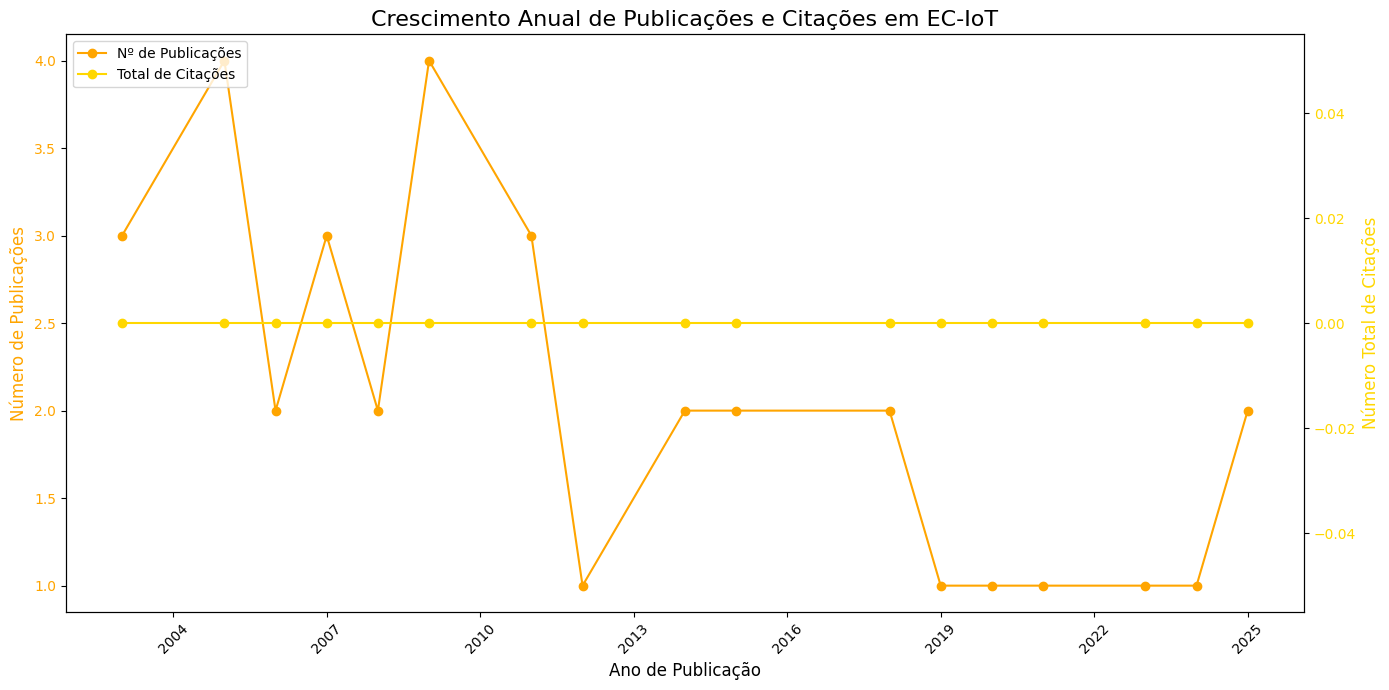

In [9]:
# Capraro: Analise 4 - Growth Trend
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Supondo que 'df' já foi carregado e está disponível no ambiente.
# df = pd.read_csv('Base Consolidada 2025.csv')

# --- Início do Código Modificado para a Análise 4 ---

print("Iniciando a Análise 4: Tendência de Crescimento (Gráficos de Linha Dupla)...")

# Passo 1: Agrupar os dados por ano e calcular as métricas.
yearly_stats = df.groupby('Publication Year').agg(
    number_of_publications=('Article Title', 'count'),
    total_citations=('Times Cited, All Databases', 'sum')
).reset_index()

yearly_stats = yearly_stats[yearly_stats['Publication Year'] >= 2003]
yearly_stats = yearly_stats.sort_values('Publication Year')

print("\nDados agregados dos últimos 5 anos para verificação:")
print(yearly_stats.tail())

# Passo 2: Criar o gráfico de eixo duplo com duas linhas.
fig, ax1 = plt.subplots(figsize=(14, 7))

# Cores para cada linha, conforme solicitado
color_publications = 'orange'
color_citations = 'gold'

# Eixo 1 (Esquerda): Linha para o Número de Publicações
ax1.set_xlabel('Ano de Publicação', fontsize=12)
ax1.set_ylabel('Número de Publicações', color=color_publications, fontsize=12)
ax1.plot(yearly_stats['Publication Year'], yearly_stats['number_of_publications'], 
         color=color_publications, marker='o', linestyle='-', label='Nº de Publicações')
ax1.tick_params(axis='y', labelcolor=color_publications)
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.xticks(rotation=45)

# Eixo 2 (Direita): Linha para o Total de Citações
ax2 = ax1.twinx()
ax2.set_ylabel('Número Total de Citações', color=color_citations, fontsize=12)
ax2.plot(yearly_stats['Publication Year'], yearly_stats['total_citations'], 
         color=color_citations, marker='o', linestyle='-', label='Total de Citações')
ax2.tick_params(axis='y', labelcolor=color_citations)

# Passo 3: Finalizar e salvar o gráfico.
plt.title('Crescimento Anual de Publicações e Citações em EC-IoT', fontsize=16)
fig.tight_layout()

# Adicionar uma legenda única para ambas as linhas
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

# Salvar a imagem do gráfico
output_filename = 'output_analise4.png'
plt.savefig(output_filename)

print(f"\nGráfico da Análise 4  gerado e salvo como '{output_filename}'")

***

#### 5: Analysis of Main Research Institutions

> *3.5. Analysis of Main Research Institutions.* From 2005 to 2020, Beijing University of Posts Telecommunications has published 115 literature studies, accounting for 4.21% of all literature studies in this field.
> ...
> The top 10 research institutions with the most published literature studies are shown in Figure 4.
> As can be seen from Figure 4, the top 10 research institutions are dominated by universities, and Chinese research institutions are the majority.

- Objetivo aqui é replicar o gráfico da figura 4. Os nomes das instituições já devem estar padronizados na base de dados, só puxar tudo da mesma coluna

**Figura 4:**

<img src="Images/Pasted image 20250816191951.png">

In [10]:
# Capraro: Analise 5 - Main Institutions

# Supondo que 'df' já foi carregado e está disponível no ambiente.
# df = pd.read_csv('Base Consolidada 2025.csv')

# --- Início do Código para a Análise 5 ---

print("Iniciando a Análise 5: Principais Instituições de Pesquisa...")

# Passo 1: Identificar e processar a coluna de afiliações.
affiliation_column = 'Affiliations'

if affiliation_column not in df.columns:
    print(f"ERRO: A coluna '{affiliation_column}' não foi encontrada no DataFrame.")
    print(f"Por favor, verifique o nome da coluna de afiliações e atualize a variável 'affiliation_column'.")
    print(f"Colunas disponíveis: {df.columns.tolist()}")
else:
    # Remove linhas que não têm dados de afiliação
    df_cleaned = df.dropna(subset=[affiliation_column])
    
    # Separa as afiliações que estão juntas na mesma linha (delimitador ';')
    all_institutions = df_cleaned[affiliation_column].str.split(';').explode()
    
    # Limpa espaços em branco extras de cada nome
    all_institutions = all_institutions.str.strip()

    # Passo 2: Contar as publicações por instituição e pegar o top 10.
    top_10_institutions = all_institutions.value_counts().head(10)

    print("\nAs 10 instituições com mais publicações são:")
    print(top_10_institutions)

    # Passo 3: Criar o gráfico de barras horizontais.
    # A LINHA ABAIXO FOI ALTERADA PARA INVERTER A ORDEM DO GRÁFICO
    top_10_institutions = top_10_institutions.sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(12, 8))

    # --- ALTERAÇÃO AQUI ---
    # Adicionado o parâmetro 'height' para diminuir a altura das barras
    bars = ax.barh(top_10_institutions.index, top_10_institutions.values, color='skyblue', height=0.4)
    
    # --- ALTERAÇÃO AQUI ---
    # Aumentado o tamanho da fonte dos rótulos e do título
    ax.set_xlabel('Número de Publicações', fontsize=18)
    ax.set_ylabel('Instituição de Pesquisa', fontsize=18)
    ax.set_title('Top 10 Instituições por Número de Publicações', fontsize=18)
    
    # Aumentar o tamanho da fonte dos ticks (os nomes das instituições)
    ax.tick_params(axis='y', labelsize=16)


    # Adicionar o número de publicações no final de cada barra
    for bar in bars:
        width = bar.get_width()
        # --- ALTERAÇÃO AQUI ---
        # Aumentado o tamanho da fonte do número em cada barra
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
                f'{int(width)}',
                ha='left', va='center', fontsize=16)

    # Ajustar a margem para os números não serem cortados
    ax.margins(x=0.1)
    plt.tight_layout()

    # Salvar a imagem do gráfico
    output_filename = 'output_analise5_top_institutions.png'
    plt.savefig(output_filename)

    print(f"\nGráfico da Análise 5 (ordem invertida) gerado e salvo como '{output_filename}'")

Iniciando a Análise 5: Principais Instituições de Pesquisa...
ERRO: A coluna 'Affiliations' não foi encontrada no DataFrame.
Por favor, verifique o nome da coluna de afiliações e atualize a variável 'affiliation_column'.
Colunas disponíveis: ['PT', 'Authors', 'BA', 'BE', 'GP', 'Author Full Names', 'BF', 'CA', 'Article Title', 'Source Title', 'SE', 'BS', 'LA', 'DT', 'CT', 'CY', 'CL', 'SP', 'HO', 'Author Keywords', 'Keywords Plus', 'AB', 'Addresses', 'C3', 'Reprint Addresses', 'EM', 'RI', 'OI', 'FU', 'FP', 'FX', 'CR', 'NR', 'Times Cited, WoS Core', 'Times Cited, All Databases', 'U1', 'U2', 'Publisher', 'PI', 'PA', 'SN', 'EI', 'BN', 'Journal ISO Abbreviation', 'Journal Abbreviation', 'PD', 'Publication Year', 'VL', 'IS', 'PN', 'SU', 'SI', 'MA', 'BP', 'EP', 'AR', 'DI', 'DL', 'D2', 'EA', 'PG', 'WC', 'WE', 'SC', 'GA', 'PM', 'OA', 'HC', 'HP', 'DA', 'UT']


***

#### 6: Analysis of Notable Countries/Regions

> *3.6. Analysis of Notable Countries/Regions*. Considerable efforts have been made to promote the development of EC-IoT to generate knowledge that can be used to solve problems encountered in practical applications of IoT. The top 10 most published countries are shown in Figure 5.
> ...
> A geographic visualization of research co-occurrence network is shown in Figure 6. According to Figure 6, countries all over the world attach great importance to EC-IoT, and there are three research intensive regions in the world, namely, Europe, southeast North America, and Southeast Asia.

- A análise da figura 5 parece ser simples de replicar
- Para a figura 6, os autores não parecem ter uma metodologia muito bem definida para o que é "co-ocorrência de pesquisa". A impressão que tenho é que eles só plotaram no mapa as coordenadas de cada instituição mencionada na base de dados e circularam onde tem mais densidade de instituições
	- Acho interessante fazer uma análise mais detalhada aqui (se tivermos tempo): podemos acabar achando regiões ligeiramente diferentes com uma metodologia mais cuidadosa (por ex. podemos achar um quarto cluster de pesquisa no sudeste dos EUA, na região da Califórnia)

**Figura 5:**

<img src="Images/Pasted image 20250816192542.png">

**Figura 6:**

<img src="Images/Pasted image 20250816192413.png">

In [ ]:
# TODO Jacobi: Analise 6 - Main Countries/Regions

***

#### 7: Analysis of Hotspots

> *3.7. Analysis of Hotspots.* Keywords are an important part of the literature, which highly condense the content of the literature.
> ...
> The minimum number of occurrences of a keyword was set 40 in VOSviewer. After merging EC-IoT and its synonyms, four clusters of high-frequency keywords were obtained, whose nodes of the same color belong to the same cluster.
> ...
> Keywords of “edge computing,” “Internet of Things,” “Internet,” and “IoT” are not shown because literature studies retrieved all related to “edge computing” and “Internet of Things.”
> 
> 1. **Cluster 1** is the study of specific difficult problems of EC-IoT, as shown in the **red** node region. The specific problems of EC-IoT include resource management, resource allocation, computation offloading, energy consumption, and delay.
> 2. **Cluster 2** is the study of the overall architecture of EC-IoT, as shown in the **green** node region. Through the optimization and innovation of the overallarchitecture, the protection of privacy and security will be further increased.
> 3. **Cluster 3** is the study of EC-IoT applications, as shown in the **blue** node region. Mobile computing is combined with big data technology and artificial intelligence algorithms to make EC-IoT better applied in smart homes, smart city, and some other fields. 
> 4. **Cluster 4** is the study of mobile edge computing (MEC) with 5G, as shown in **yellow** node area. The development of 5G ensures high bandwidth and low latency in the transmission process, which provides the network security for EC-IoT. With the continuous maturity of 5G technology, the study of MEC will also usher in rapid development.
> 
> ...
> The literature keyword analysis not only provides an effective way for the knowledge structure of the research field but also provides an effective way for the exploration of the development trend in the field. Therefore, it can be speculated that problems of EC-IoT related to resource management, resource allocation, computation offloading, energy consumption, and delay will be further studied in the future.

- Aqui a análise é feita inteiramente no VOSViewer, então não precisamos de nenhum tratamento adicional de dados em Python.
- Única configuração necessária é `Minimum number of keyword ocurrences = 40`